<a href="https://colab.research.google.com/github/MJ-SU/AI_demo_in_colab/blob/main/%E9%81%BA%E5%82%B3%E6%BC%94%E7%AE%97%E6%B3%95%E5%9C%96%E5%83%8F%E9%87%8D%E5%BB%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 遺傳演算法圖像重建（Genetic Algorithm Image Reconstruction）

讓一雜訊圖片透過模擬生物的族群基因選擇、交配、突變不斷演化，逐漸逼近使用者上傳的目標灰階圖片。

**流程：** 上傳圖片 → 前處理（灰階化 / 降採樣）→ 初始化族群 → 迭代演化（選擇 / 交配 / 突變 / 菁英保留）→ 即時顯示收斂過程 → 輸出下載最佳結果

此演算法不需 GPU。

## 1️環境設定與套件匯入

In [3]:
!pip install -q scikit-image ipywidgets
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from multiprocessing import Pool
import imageio.v2 as imageio
import ipywidgets as widgets
from IPython.display import display, clear_output
from io import BytesIO

print('套件載入完成')

!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

print('中文字型已下載')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 14.6 MB/s eta 0:00:00
套件載入完成
--2026-07-14 15:57:36--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.251.8.102, 142.251.8.113, 142.251.8.138, ...
Connecting to drive.google.com (drive.google.com)|142.251.8.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-07-14 15:57:37--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.157.132, 2404:6800:4008:c13::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.157.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta

## 2️上傳圖片（前端介面）
點擊下方按鈕即可從本機選擇圖片上傳，彩色或灰階圖片皆可。

In [4]:
from google.colab import files

# 全域變數：儲存使用者上傳的原始圖片
original_img = None

upload_button = widgets.Button(description='上傳圖片', button_style='primary')
upload_output = widgets.Output()

def on_upload_clicked(b):
    global original_img
    with upload_output:
        clear_output(wait=True)
        uploaded = files.upload()
        if not uploaded:
            print('未偵測到上傳檔案')
            return
        filename = list(uploaded.keys())[0]
        original_img = imageio.imread(BytesIO(uploaded[filename]))
        print(f'上傳成功：{filename}')
        print('原始圖片形狀:', original_img.shape)
        plt.figure(figsize=(4, 4))
        plt.imshow(original_img, cmap='gray' if original_img.ndim == 2 else None)
        plt.title('原始上傳圖片')
        plt.axis('off')
        plt.show()

upload_button.on_click(on_upload_clicked)
display(upload_button, upload_output)

Button(button_style='primary', description='上傳圖片', style=ButtonStyle())

Output()

## 3️圖片前處理（灰階化 / 降採樣）

- **灰階化**：若上傳的是彩色圖片，使用加權平均法轉換為灰階。
- **降採樣**：像素數等於基因數量，圖片越大演化越慢，可用倍率縮小圖片（例如倍率 2 代表長寬各取一半）。

In [5]:
processed_img = None  # 前處理後、GA 要逼近的目標圖片

downsample_slider = widgets.IntSlider(value=4, min=4, max=8, step=1, description='降採樣倍率:')
process_button = widgets.Button(description='處理圖片', button_style='success')
process_output = widgets.Output()

def preprocess_image(img, downsample=2):
    # 若為彩色圖片（RGB / RGBA），轉換為灰階
    if img.ndim == 3:
        img = np.dot(img[..., :3], [0.299, 0.587, 0.114])
    img = img.astype(np.uint8)
    # 降採樣以加速演算法
    img = img[::downsample, ::downsample]
    return img

def on_process_clicked(b):
    global processed_img
    with process_output:
        clear_output(wait=True)
        if original_img is None:
            print('請先完成步驟 2 上傳圖片')
            return
        processed_img = preprocess_image(original_img, downsample_slider.value)
        print('處理後圖片形狀:', processed_img.shape, '｜ 基因數量 (像素數):', processed_img.size)
        plt.figure(figsize=(4, 4))
        plt.imshow(processed_img, cmap='gray')
        plt.title('前處理後的目標圖片')
        plt.axis('off')
        plt.show()

process_button.on_click(on_process_clicked)
display(downsample_slider, process_button, process_output)

IntSlider(value=4, description='降採樣倍率:', max=8, min=4)

Button(button_style='success', description='處理圖片', style=ButtonStyle())

Output()

## 4️遺傳演算法核心函式

每個個體 (individual) 是一串長度等於「目標圖片像素數」的基因，數值代表灰階像素值 (0-255)。
適應度 (fitness) 以個體還原成圖片後，與目標圖片的 **結構相似性指標 (SSIM)** 來衡量，數值介於 -1 ~ 1，越接近 1 代表越相似。

In [6]:
# --- 初始化族群：隨機產生 n_individuals 個個體，每個個體有 n_genes 個基因 ---
def init_population(n_individuals, n_genes):
    return np.random.rand(n_individuals, n_genes) * 255

# --- 將影像數值範圍縮放到 0-255，方便與目標圖片比較 ---
def scale(img):
    return (img - np.amin(img)) / (np.amax(img) - np.amin(img) + 1e-6) * 255

# --- 單一個體的適應度評估（放在全域作用域，供多進程呼叫）---
def evaluate_individual(individual, real_img_shape, real_img):
    real_imgh, real_imgw = real_img_shape
    individual_img = individual.reshape([real_imgh, real_imgw])
    individual_img = scale(individual_img)
    return ssim(real_img, individual_img, win_size=7, data_range=255)

# --- 平行評估整個族群的適應度 ---
def evaluate_fitness_parallel(population, real_img):
    real_imgh, real_imgw = real_img.shape
    real_img_shape = (real_imgh, real_imgw)
    with Pool() as pool:
        fitness_vals = pool.starmap(
            evaluate_individual,
            [(individual, real_img_shape, real_img) for individual in population]
        )
    return fitness_vals

# --- 選擇：淘汰適應度最低的 1/4 個體，其餘作為交配的親代 ---
def select(population, fitness_vals):
    n_inds = population.shape[0]
    n_discard = n_inds // 4
    sorted_inds = [ind for _, ind in sorted(
        zip(fitness_vals, range(len(fitness_vals))), key=lambda pair: pair[0]
    )]
    return np.delete(population, sorted_inds[:n_discard], axis=0)

# --- 交配：隨機挑選親代配對，以基因遮罩方式產生子代 ---
def reproduction(parents):
    n_parents, n_genes = parents.shape[0], parents.shape[1]
    combinations = [[p1, p2] for p1 in range(n_parents - 1) for p2 in range(p1 + 1, n_parents)]
    comb_sample = list(np.random.choice(len(combinations), size=(n_parents * 2), replace=True))
    combinations = [comb for i, comb in enumerate(combinations) if i in comb_sample]

    children = np.zeros((len(combinations), n_genes))
    for i_comb, comb in enumerate(combinations):
        parent1, parent2 = parents[comb[0], :], parents[comb[1], :]
        mask1 = np.float32(np.random.rand(n_genes) > 0.5)
        mask2 = np.float32(mask1 == 0)
        parent1, parent2 = parent1 * mask1, parent2 * mask2
        children[i_comb, :] = parent1 + parent2
    return children

# --- 突變：對子代基因加入隨機雜訊，強度隨機決定 ---
def mutate(children):
    n_children, n_genes = children.shape
    mutation_strength = np.random.randint(0, 50, 1)[0]
    mutations = np.random.randn(n_children, n_genes) * mutation_strength
    children = children + mutations

    min_vals = np.amin(children, 1)
    mutation_map = np.float32(np.random.rand(n_children, n_genes) < 0.999)
    children *= mutation_map
    children += (min_vals * np.float32(mutation_map == 0).transpose()).transpose()
    return children

# --- 菁英保留：直接保留適應度最高的 n_elite 個個體進入下一代 ---
def keep_elite(population, fitness_vals, n_elite=2):
    elite_indices = np.argsort(fitness_vals)[-n_elite:]
    return population[elite_indices]

# --- 產生下一代族群：合併親代與子代，並裁切至族群大小 ---
def make_next_generation(parents, children, pop_size):
    combined = np.concatenate((parents, children), 0)
    if len(combined) > pop_size:
        return combined[:pop_size]
    return combined

print('GA 核心函式定義完成')

GA 核心函式定義完成


## 5️主程式（含即時迭代視覺化）

與原始版本不同的地方：使用 `clear_output(wait=True)` 在同一個輸出區塊中即時更新畫面，
看起來就像動畫一樣呈現「族群逐代逼近目標圖片」的過程，而不是每次都印出新的一批圖。
另外加入 `max_generations` 上限，避免因為門檻設太高而讓程式無限跑下去。

In [7]:
# --- 畫出目前最佳個體 / 目標圖片 / 收斂曲線，抽成獨立函式方便重複呼叫 ---
def _render_progress(generation, img, population, fitness_vals, best_fitness_history,
                      desired_fitness, target_output, final=False):
    with target_output:
        clear_output(wait=True)
        best_idx = int(np.argmax(fitness_vals))
        best_img = scale(population[best_idx].reshape(img.shape))

        fig = plt.figure(figsize=(13, 4))
        sub1 = fig.add_subplot(131)
        sub2 = fig.add_subplot(132)
        sub3 = fig.add_subplot(133)

        title_tag = '（最終結果）' if final else ''
        sub1.imshow(best_img, cmap='gray')
        sub1.set_title(f'目前最佳個體 (第 {generation} 代){title_tag}')
        sub1.axis('off')

        sub2.imshow(img, cmap='gray')
        sub2.set_title('目標圖片')
        sub2.axis('off')

        sub3.plot([g for g, _ in best_fitness_history], [f for _, f in best_fitness_history])
        sub3.axhline(desired_fitness, color='red', linestyle='--', linewidth=1)
        sub3.set_xlabel('Generation')
        sub3.set_ylabel('Best Fitness (SSIM)')
        sub3.set_title('適應度收斂曲線')

        plt.tight_layout()
        plt.show()
        print(f'世代: {generation} ｜ 最佳適應度: {max(fitness_vals):.4f} ｜ 目標: {desired_fitness}')
        if final:
            print('演化結束')


def run_genetic_algorithm(img, pop_size=30, desired_fitness=0.85, max_generations=5000,
                           update_interval=50, live_output=None):
    generation = 0
    best_fitness_history = []
    target_output = live_output if live_output is not None else widgets.Output()

    population = init_population(pop_size, img.size)
    fitness_vals = evaluate_fitness_parallel(population, img)

    while max(fitness_vals) < desired_fitness and generation < max_generations:
        elite = keep_elite(population, fitness_vals)
        parents = select(population, fitness_vals)
        children = reproduction(parents)
        children = mutate(children)

        population = np.vstack([elite, make_next_generation(parents, children, pop_size - len(elite))])
        fitness_vals = evaluate_fitness_parallel(population, img)
        best_fitness_history.append([generation, max(fitness_vals)])

        if generation % update_interval == 0 or max(fitness_vals) >= desired_fitness:
            _render_progress(generation, img, population, fitness_vals,
                              best_fitness_history, desired_fitness, target_output)

        generation += 1

    # 不論是「達到目標適應度」還是「跑到世代上限」而結束，最後都強制畫一次最終結果，
    # 避免最後一代剛好沒對到 update_interval 而漏掉畫面更新。
    _render_progress(generation - 1, img, population, fitness_vals,
                      best_fitness_history, desired_fitness, target_output, final=True)

    return population, fitness_vals, best_fitness_history

print('主程式定義完成')

主程式定義完成


## 6️設定參數並啟動演化（前端控制面板）

- **族群大小**：每一代個體的數量，越大探索能力越強但越慢。
- **目標適應度**：SSIM 達到此值即停止演化（越接近 1 代表越相似）。
- **最大世代數**：安全上限，避免長時間跑不完。
- **更新頻率**：每隔幾代更新一次畫面。

In [10]:
pop_size_widget = widgets.IntSlider(value=80, min=80, max=200, step=10, description='族群大小:')
fitness_widget = widgets.FloatSlider(value=0.7, min=0.5, max=0.99, step=0.01, description='目標適應度:')
max_gen_widget = widgets.IntText(value=5000, description='最大世代數:')
update_interval_widget = widgets.IntSlider(value=200, min=1, max=500, step=1, description='更新頻率:')
run_button = widgets.Button(description='開始演化', button_style='danger')
live_output = widgets.Output()

# 全域變數：儲存最終結果，供下一步下載使用
final_population, final_fitness_vals, final_history = None, None, None

def on_run_clicked(b):
    global final_population, final_fitness_vals, final_history
    if processed_img is None:
        with live_output:
            clear_output(wait=True)
            print('請先完成步驟 2、3：上傳並處理圖片')
        return
    final_population, final_fitness_vals, final_history = run_genetic_algorithm(
        processed_img,
        pop_size=pop_size_widget.value,
        desired_fitness=fitness_widget.value,
        max_generations=max_gen_widget.value,
        update_interval=update_interval_widget.value,
        live_output=live_output,
    )

run_button.on_click(on_run_clicked)
display(pop_size_widget, fitness_widget, max_gen_widget, update_interval_widget, run_button, live_output)

IntSlider(value=80, description='族群大小:', max=200, min=80, step=10)

FloatSlider(value=0.5, description='目標適應度:', max=0.99, min=0.5, step=0.01)

IntText(value=10000, description='最大世代數:')

IntSlider(value=200, description='更新頻率:', max=500, min=1)

Button(button_style='danger', description='開始演化', style=ButtonStyle())

Output()

## 7️輸出與下載最佳結果
演化完成後，執行此區塊將最終最佳個體另存為 PNG 圖片並下載。

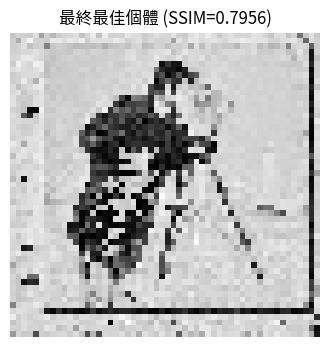

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
def save_and_download_best(filename='ga_best_result.png'):
    if final_population is None:
        print('尚未執行演化，請先完成步驟 6')
        return
    best_idx = int(np.argmax(final_fitness_vals))
    best_img = scale(final_population[best_idx].reshape(processed_img.shape)).astype(np.uint8)

    plt.figure(figsize=(4, 4))
    plt.imshow(best_img, cmap='gray')
    plt.title(f'最終最佳個體 (SSIM={final_fitness_vals[best_idx]:.4f})')
    plt.axis('off')
    plt.show()

    imageio.imwrite(filename, best_img)
    files.download(filename)

save_and_download_best()